# Propaganda Detection

In [4]:
#Standard Libraries
import sys
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn (classic ML Libraries)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# tensorflow libraries
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# Deep Learning Libraries
from transformers import BertTokenizer, BertForSequenceClassification, BertTokenizerFast, BertForTokenClassification, BertForQuestionAnswering
import torch
from torch.utils.data import DataLoader, Dataset
from torch.optim import AdamW

# Other Utilities Libraries
from scipy.sparse import hstack
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")


# Data Collection


In [6]:
# Reads file
def read_data(fname):
    return pd.read_csv(fname, delimiter = "\t", quotechar = '|')


In [7]:
# Load dataset
train_data_df = read_data("propaganda_train.tsv")
val_data_df = read_data("propaganda_val.tsv")


In [8]:
# Display 10 rows
display(train_data_df.tail(10))


Dataset Overview:


,label,tagged_in_context
2550,not_propaganda,"Trump undid the Iran deal, which Russia favore..."
2551,"exaggeration,minimisation",“I would like to take this opportunity to make...
2552,flag_waving,Trump To Jeff Sessions: Put An End to Russia P...
2553,causal_oversimplification,<BOS> Neither the Democrat leadership nor the ...
2554,not_propaganda,Now how <BOS> does Farage propose to do <EOS> ...
2555,not_propaganda,<BOS> We support and appreciate <EOS> your bus...
2556,not_propaganda,International Atomic Energy Agency (IAEA) Dire...
2557,not_propaganda,What has been done: there has been work on for...
2558,not_propaganda,This is <BOS> the law of gradualness not the g...
2559,"name_calling,labeling","In it, Jews are described as: “arrogant,” “jea..."


# Data Pre-Processing

In [9]:
# -----------------Handling Duplicate Rows-----------------

for name, df in [("train_data_df", train_data_df), ("val_data_df", val_data_df)]:
    if df.duplicated().any(): # Check any duplicates
        duplicate_rows = df.duplicated().sum()  # Count
        df.drop_duplicates(keep = 'first', inplace = True) # Remove

        print(f"The {name} DataFrame contained {duplicate_rows} duplicates")
    else:
        print(f"The {name} DataFrame has no duplicates.")


The train_data_df DataFrame contained 10 duplicates and they were removed..
The val_data_df DataFrame has no duplicates.


In [10]:
# -----------------Preprocessing function-----------------

def preprocess_dataframe(df):
    """ Preprocessing function to extract span, sentence, and features"""

    features = []
    for _, row in df.iterrows():
        full_sentence = row["tagged_in_context"]
        label = row["label"]

        # Extract span using regex
        span_match = re.search(r"<BOS>(.*?)<EOS>", full_sentence)
        if not span_match:
            continue
        span = span_match.group(1).strip()
        span_begin = span_match.start()

        # Remove tags
        cleaned_text = re.sub(r"<BOS>|<EOS>", "", full_sentence).strip()

        # Feature engineering
        relative_pos = span_begin / len(full_sentence)
        span_len = len(span.split())
        text_len = len(cleaned_text.split())

        features.append({"label": label,
                         "span": span,
                         "text": cleaned_text,
                         "relative_position": relative_pos,
                         "span_length": span_len,
                         "text_length": text_len
                        })
    return pd.DataFrame(features)


In [11]:
# Calling the function to preprocess
processed_train_data_df = preprocess_dataframe(train_data_df)
processed_val_data_df = preprocess_dataframe(val_data_df)

# Combine the span & full text into one field for TF-IDF vectorization
processed_train_data_df["combined_text"] = processed_train_data_df["span"] + " " + processed_train_data_df["text"]
processed_val_data_df["combined_text"] = processed_val_data_df["span"] + " " + processed_val_data_df["text"]


In [12]:
# show DataFrame
display(processed_train_data_df.head(5))

,label,span,text,relative_position,span_length,text_length,combined_text
0,not_propaganda,he,"No, he will not be confirmed.",0.095238,1,6,"he No, he will not be confirmed."
1,not_propaganda,won’t make things any worse than they are for ...,This declassification effort won’t make thing...,0.278846,11,14,won’t make things any worse than they are for ...
2,flag_waving,American people,"""The Obama administration misled the American...",0.260563,2,21,"American people ""The Obama administration misl..."
3,not_propaganda,and,“It looks like we’re capturing the demise of t...,0.295775,1,34,and “It looks like we’re capturing the demise ...
4,not_propaganda,"Location: Westerville, Ohio","Location: Westerville, Ohio",0.000000,3,3,"Location: Westerville, Ohio Location: Westervi..."


# Exploratory Data Analysis

In [13]:
# Number of samples per class
label_counts = processed_train_data_df['label'].value_counts().sort_values(ascending = False)

# Average text length per class
avg_text_length = processed_train_data_df.groupby('label')['text_length'].mean()

# Average span length per class
avg_span_length = processed_train_data_df.groupby('label')['span_length'].mean()


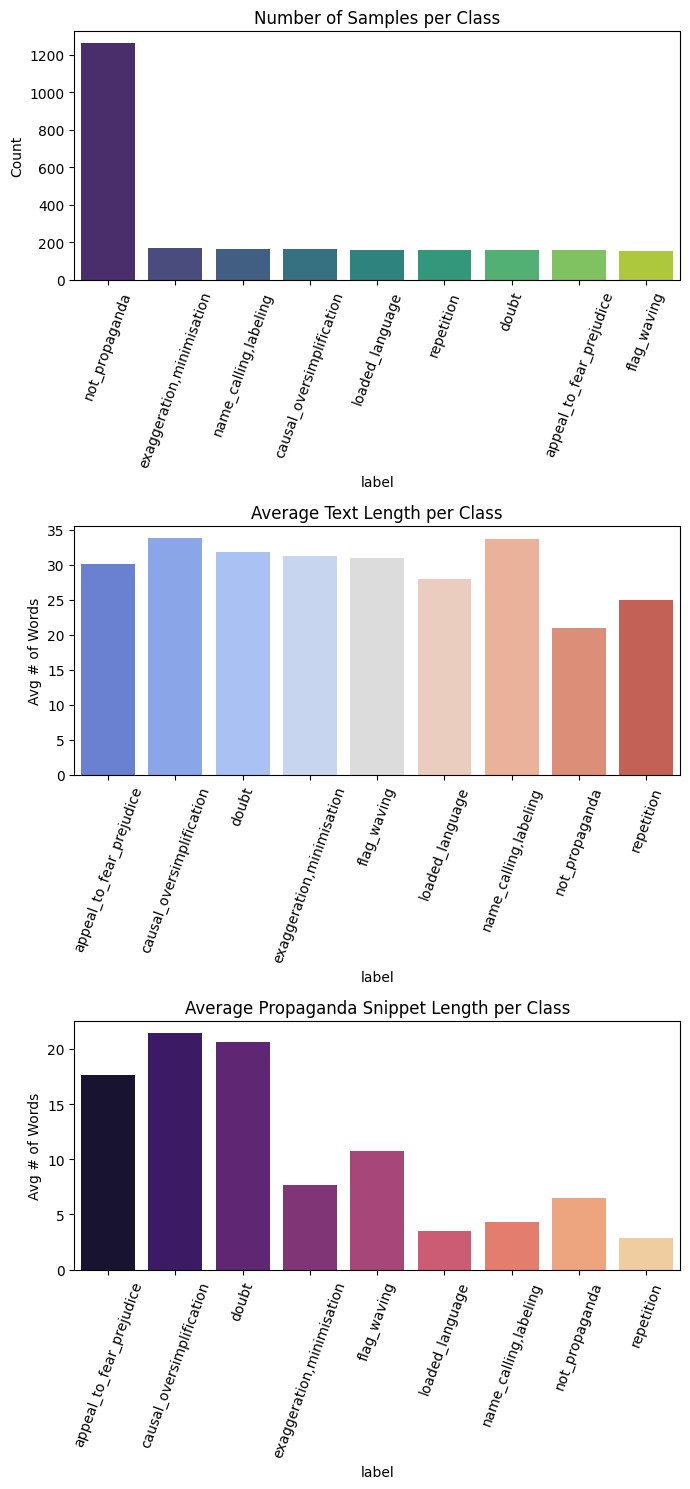

In [14]:
# Create the plot
plt.figure(figsize = (7, 15))  # Set figure size

# Bar plot for label distribution
plt.subplot(3, 1, 1)
sns.barplot(x = label_counts.index, y = label_counts.values, palette = "viridis")
plt.title("Number of Samples per Class")
plt.ylabel("Count")
plt.xticks(rotation = 70)

# Bar plot for average sentence length
plt.subplot(3, 1, 2)
sns.barplot(x = avg_text_length.index, y = avg_text_length.values, palette = "coolwarm")
plt.title("Average Text Length per Class")
plt.ylabel("Avg # of Words")
plt.xticks(rotation = 70)

# Bar plot for average span length
plt.subplot(3, 1, 3)
sns.barplot(x = avg_span_length.index, y = avg_span_length.values, palette = "magma")
plt.title("Average Propaganda Snippet Length per Class")
plt.ylabel("Avg # of Words")
plt.xticks(rotation = 70)

plt.tight_layout()
plt.show()

# Data Modelling, Evaluation and Tuning

# Task 1

## Approach 1: TF-IDF Features + Logistic Regression

A traditional baseline model using TF-IDF vectorization of sentences combined with handcrafted span features (e.g., span length, relative position). A logistic regression classifier is trained to predict the propaganda technique label based on this feature set.

In [15]:
# Combine the span & full text into one field for TF-IDF vectorization
processed_train_data_df["combined_text"] = processed_train_data_df["span"] + " " + processed_train_data_df["text"]
processed_val_data_df["combined_text"] = processed_val_data_df["span"] + " " + processed_val_data_df["text"]


We use bigrams to capture short phrases that often represent propaganda (e.g., 'fake news', 'national pride'). We limit to 5000 features for efficiency

In [16]:
# -----------------TF-IDF Vectorization-----------------

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(ngram_range = (1, 2), max_features = 5000) # (unigrams + bigrams)

# Fit on training data and transform both sets
X_train_tfidf = vectorizer.fit_transform(processed_train_data_df["combined_text"])
X_val_tfidf = vectorizer.transform(processed_val_data_df["combined_text"])


In [17]:
# -----------------Prepare Numerical Features-----------------

# Select numeric features
num_features = ["relative_position", "span_length", "text_length"]

# Standardize numerical features
scaler = StandardScaler()
X_train_num = scaler.fit_transform(processed_train_data_df[num_features])
X_val_num = scaler.transform(processed_val_data_df[num_features])


In [18]:
# -----------------Combine TF-IDF and Numeric Features-----------------

# Combine sparse TF-IDF matrix and dense numerical feature array
X_train_final = hstack([X_train_tfidf, X_train_num])
X_val_final = hstack([X_val_tfidf, X_val_num])


In [19]:
# -----------------Train Logistic Regression Classifier-----------------

# Target labels
y_train = processed_train_data_df["label"]
y_val = processed_val_data_df["label"]

# Train the model
logistic_model = LogisticRegression(max_iter = 1000)
logistic_model.fit(X_train_final, y_train)


LogisticRegression(max_iter=1000)

In [20]:
# -----------------Evaluate the Model-----------------

y_pred = logistic_model.predict(X_val_final)
conf_matrix = confusion_matrix(y_val, y_pred)

# Print evaluation metrics
print(f'Classification Report for Validation Set:\n\n {classification_report(y_val, y_pred)}')


Classification Report for Validation Set:

                            precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.42      0.12      0.18        43
causal_oversimplification       0.48      0.29      0.36        35
                    doubt       0.41      0.21      0.28        43
exaggeration,minimisation       0.25      0.07      0.11        30
              flag_waving       0.71      0.27      0.39        45
          loaded_language       1.00      0.03      0.05        39
    name_calling,labeling       0.43      0.09      0.15        34
           not_propaganda       0.59      0.97      0.73       331
               repetition       0.67      0.10      0.17        40

                 accuracy                           0.57       640
                macro avg       0.55      0.24      0.27       640
             weighted avg       0.57      0.57      0.48       640



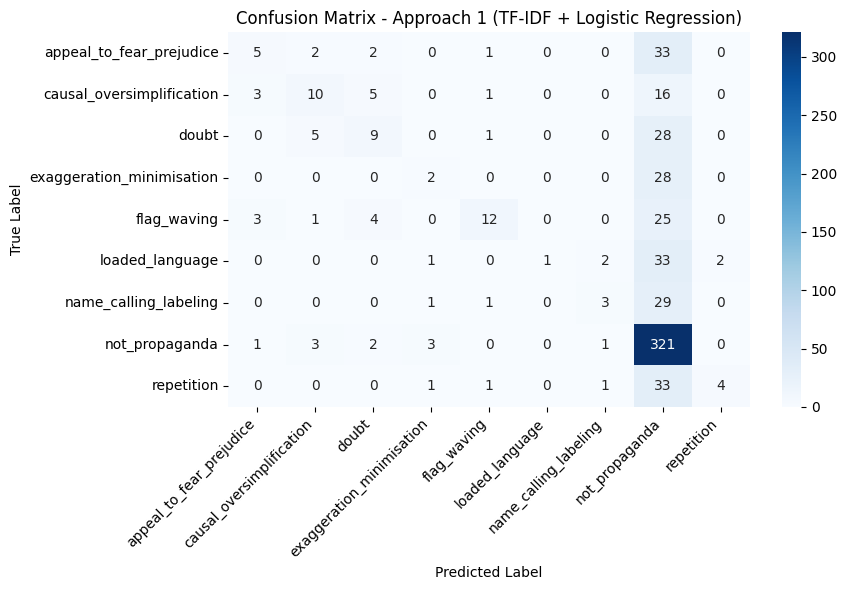

In [21]:
# -----------------Confusion matrix-----------------

labels = ["appeal_to_fear_prejudice",
          "causal_oversimplification",
          "doubt",
          "exaggeration_minimisation",
          "flag_waving",
          "loaded_language",
          "name_calling_labeling",
          "not_propaganda",
          "repetition"
         ]

# Plot using seaborn heatmap
plt.figure(figsize = (9, 6))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = labels, yticklabels = labels)

plt.title("Confusion Matrix - Approach 1 (TF-IDF + Logistic Regression)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()


### Hyperparameter Tuning: Logistic Regression on TF-IDF + Features through GridSearchCV

In [22]:
# -----------------Hyperparameter Grid-----------------

# Define the grid of hyperparameters
param_grid = {'C': [0.01, 0.1, 1, 10], 'class_weight': [None, 'balanced']}

# Grid Search with Cross-Validation
# re-defining the model
log_reg_model = LogisticRegression(max_iter = 1000)
# Grid search setup
grid_search = GridSearchCV(estimator = log_reg_model,
                           param_grid = param_grid,
                           cv = 3,                         # 3-fold cross-validation
                           scoring = 'f1_macro',           # Evaluate using macro-average F1
                           n_jobs = -1,                    # Use all available CPU cores
                           verbose = 1
                          )
# Grid search on training data
grid_search.fit(X_train_final, y_train)

# Show best parameters
print("\nBest Parameters:", grid_search.best_params_)

# Use the best model
best_lr_model = grid_search.best_estimator_

# Evaluate on test Set
y_pred_best = best_lr_model.predict(X_val_final)

# Print classification report
print(classification_report(y_val, y_pred_best))


Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters: {'C': 10, 'class_weight': 'balanced'}
                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.39      0.40      0.39        43
causal_oversimplification       0.41      0.43      0.42        35
                    doubt       0.43      0.47      0.44        43
exaggeration,minimisation       0.28      0.33      0.30        30
              flag_waving       0.61      0.60      0.61        45
          loaded_language       0.17      0.13      0.15        39
    name_calling,labeling       0.28      0.24      0.25        34
           not_propaganda       0.74      0.76      0.75       331
               repetition       0.35      0.33      0.34        40

                 accuracy                           0.57       640
                macro avg       0.41      0.41      0.41       640
             weighted avg       0.57      0.57      0.57       640



## Approach 2: BiLSTM

In [23]:
# -----------------Tokenization + Padding for LSTM Input-----------------

# Parameters
max_num_words = 10000      # Maximum vocabulary size
max_seq_length = 100  # Maximum length of padded sequences

# Initializing tokenizer and fit on training text
lstm_tokenizer = Tokenizer(num_words = max_num_words, oov_token = "<OOV>")
lstm_tokenizer.fit_on_texts(processed_train_data_df["combined_text"])

# Convert text to sequences
X_train_seq = lstm_tokenizer.texts_to_sequences(processed_train_data_df["combined_text"])
X_val_seq = lstm_tokenizer.texts_to_sequences(processed_val_data_df["combined_text"])

# Pad sequences to fixed length
X_train_pad = pad_sequences(X_train_seq, maxlen = max_seq_length, padding = 'post')
X_val_pad = pad_sequences(X_val_seq, maxlen = max_seq_length, padding = 'post')

# shape
print("Training shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)

Training shape: (2550, 100)
Validation shape: (640, 100)


In [24]:
# -----------------Encode Target Labels-----------------

# Encode string to integers
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(processed_train_data_df["label"])
y_val_enc = label_encoder.transform(processed_val_data_df["label"])

# One-hot encode the labels for softmax classification
y_train_cat = to_categorical(y_train_enc)
y_val_cat = to_categorical(y_val_enc)

# Store number of classes for output layer
classes_num = len(label_encoder.classes_)


In [25]:
# -----------------Build LSTM Model-----------------

# Define the model
lstm_model = Sequential([Embedding(input_dim = max_num_words, output_dim = 200, input_length = max_seq_length),
                         Bidirectional(LSTM(128, implementation = 2)),
                         Dropout(0.3),
                         Dense(64, activation = 'relu'),
                         Dropout(0.2),
                         Dense(classes_num, activation = 'softmax')])

# Compile the model
lstm_model.compile(optimizer = 'adam',
                   loss = 'categorical_crossentropy',
                   metrics = ['accuracy'])

In [26]:
# -----------------Train the model-----------------

history = lstm_model.fit(X_train_pad, y_train_cat,
                         epochs  = 20,
                         batch_size = 32,
                         validation_data = (X_val_pad, y_val_cat))

Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.4600 - loss: 1.8360 - val_accuracy: 0.5312 - val_loss: 1.5441
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5195 - loss: 1.4486 - val_accuracy: 0.5391 - val_loss: 1.4801
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5855 - loss: 1.1487 - val_accuracy: 0.5156 - val_loss: 1.5696
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6948 - loss: 0.8322 - val_accuracy: 0.5312 - val_loss: 1.6557
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7857 - loss: 0.5841 - val_accuracy: 0.5344 - val_loss: 2.0868
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8921 - loss: 0.3693 - val_accuracy: 0.5234 - val_loss: 2.0316
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9412 - loss: 0.2178 - val_accuracy: 0.5172 - val_loss: 2.3665
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9727 - loss: 0.1158 - val_accuracy: 0.5422 - v

In [27]:
# -----------------Classification Report-----------------

# Get predictions
y_pred_probs = lstm_model.predict(X_val_pad)
y_pred_classes = np.argmax(y_pred_probs, axis = 1)

# Classification report
print(classification_report(y_val_enc, y_pred_classes, target_names = label_encoder.classes_))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.30      0.16      0.21        43
causal_oversimplification       0.38      0.34      0.36        35
                    doubt       0.26      0.26      0.26        43
exaggeration,minimisation       0.30      0.43      0.36        30
              flag_waving       0.54      0.49      0.51        45
          loaded_language       0.20      0.15      0.17        39
    name_calling,labeling       0.33      0.12      0.17        34
           not_propaganda       0.70      0.80      0.75       331
               repetition       0.34      0.30      0.32        40

                 accuracy                           0.55       640
                macro avg       0.37      0.34      0.35       640
             weighted avg       0.52      0.55      0.53       640



tried with different output_dim values and lstm units all got accuracy in the range 45-55

## Approach 3: BERT

In [28]:
# -----------------Tokenize with BERT-----------------

# prepare input
train_texts = processed_train_data_df["combined_text"].tolist()
train_labels = processed_train_data_df["label"].tolist()
val_texts = processed_val_data_df["combined_text"].tolist()
val_labels = processed_val_data_df["label"].tolist()

# tokenize
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = bert_tokenizer(train_texts, truncation = True, padding = True, max_length = 128)
val_encodings = bert_tokenizer(val_texts, truncation = True, padding = True, max_length = 128)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [29]:
# -----------------Encode Labels-----------------

# Encode labels to integers
train_labels_enc = label_encoder.fit_transform(train_labels)
val_labels_enc = label_encoder.transform(val_labels)

# Save the number of classes for later use
num_classes = len(label_encoder.classes_)


In [30]:
# -----------------Preparing dataset class for HuggingFace Trainer-----------------

class PropagandaDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

# Create dataset instances
train_dataset = PropagandaDataset(train_encodings, train_labels_enc)
val_dataset = PropagandaDataset(val_encodings, val_labels_enc)


In [31]:
# -----------------Load Model-----------------

# Load BERT
bert_seq_clas_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = num_classes)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_seq_clas_model.to(device)

# Define optimizer
bert_seq_clas_optimizer = AdamW(bert_seq_clas_model.parameters(), lr = 2e-5)

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [32]:
# -----------------Train the Model-----------------

EPOCHS = 5
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")

    bert_seq_clas_model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        bert_seq_clas_optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = bert_seq_clas_model(input_ids = input_ids, attention_mask = attention_mask, labels = labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        bert_seq_clas_optimizer.step()

    avg_loss = total_loss / len(train_loader)
    print(f"Average Training Loss: {avg_loss:.4f}")



--- Epoch 1/5 ---


100%|██████████| 160/160 [00:54<00:00,  2.93it/s]


Average Training Loss: 1.5965

--- Epoch 2/5 ---


100%|██████████| 160/160 [00:55<00:00,  2.88it/s]


Average Training Loss: 1.1137

--- Epoch 3/5 ---


...

Average Training Loss: 0.7285

--- Epoch 4/5 ---


100%|██████████| 160/160 [00:55<00:00,  2.89it/s]


Average Training Loss: 0.4716

--- Epoch 5/5 ---


100%|██████████| 160/160 [00:55<00:00,  2.90it/s]

Average Training Loss: 0.2826


In [33]:
# -----------------Evaluate the Model-----------------

bert_seq_clas_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = bert_seq_clas_model(input_ids = input_ids, attention_mask = attention_mask)
        preds = torch.argmax(outputs.logits, axis = 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(all_labels, all_preds, target_names = label_encoder.classes_))


                           precision    recall  f1-score   support

 appeal_to_fear_prejudice       0.46      0.51      0.48        43
causal_oversimplification       0.46      0.60      0.52        35
                    doubt       0.57      0.30      0.39        43
exaggeration,minimisation       0.72      0.60      0.65        30
              flag_waving       0.66      0.69      0.67        45
          loaded_language       0.66      0.49      0.56        39
    name_calling,labeling       0.75      0.71      0.73        34
           not_propaganda       0.92      0.88      0.90       331
               repetition       0.32      0.60      0.42        40

                 accuracy                           0.72       640
                macro avg       0.61      0.60      0.59       640
             weighted avg       0.75      0.72      0.73       640



# Task 2
## Approach 1: BERT + BIO Tagging

In [34]:
# -----------------Generate BIO-Labeled Tokens-----------------

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def create_bio_examples(df):
    examples = []

    for _, row in df.iterrows():
        full_text = row["tagged_in_context"]
        label = row["label"]

        # Extract span and clean sentence
        span_match = re.search(r"<BOS>(.*?)<EOS>", full_text)
        if not span_match:
            continue

        span = span_match.group(1).strip()
        span_start = span_match.start()
        span_end = span_match.end()

        #sentence without tags
        clean_sentence = re.sub(r"<BOS>|<EOS>", "", full_text)

        # Tokenize sentence
        tokens = bert_tokenizer.tokenize(clean_sentence)
        input_ids = bert_tokenizer.encode(clean_sentence, add_special_tokens = False)

        # Tokenize span separately
        span_tokens = bert_tokenizer.tokenize(span)

        # Initialize all labels as "O"
        bio_labels = ["O"] * len(tokens)

        # Find span token start index
        span_start_idx = -1
        for i in range(len(tokens) - len(span_tokens) + 1):
            if tokens[i:i+len(span_tokens)] == span_tokens:
                span_start_idx = i
                break

        if span_start_idx != -1:
            bio_labels[span_start_idx] = f"B-{label}"
            for j in range(1, len(span_tokens)):
                bio_labels[span_start_idx + j] = f"I-{label}"

        examples.append({"tokens": tokens,
                         "labels": bio_labels
                        })

    return examples

# Example
bio_train_examples = create_bio_examples(train_data_df)
bio_val_examples = create_bio_examples(val_data_df)

# sample
bio_train_examples[0]

{'tokens': ['no', ',', 'he', 'will', 'not', 'be', 'confirmed', '.'],
 'labels': ['O', 'O', 'B-not_propaganda', 'O', 'O', 'O', 'O', 'O']}

In [35]:
# -----------------Convert Tokens + Labels into Tensor Dataset-----------------

bert_fast_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# Collect all label types
all_label_set = set(label for ex in bio_train_examples for label in ex["labels"])
label_list = sorted(list(all_label_set))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

# Dataset class
class TokenClassificationDataset(Dataset):
    def __init__(self, examples, bert_fast_tokenizer, max_len = 128):
        self.encodings = []
        self.labels = []

        for ex in examples:
            encoding = bert_fast_tokenizer(ex["tokens"],
                                           is_split_into_words = True,
                                           truncation = True,
                                           padding = 'max_length',
                                           max_length = max_len
                                          )

            word_ids = encoding.word_ids()
            label_ids = []
            prev_word_idx = None
            for word_idx in word_ids:
                if word_idx is None:
                    label_ids.append(-100)
                elif word_idx != prev_word_idx:
                    label_ids.append(label2id[ex["labels"][word_idx]])
                else:
                    label_ids.append(label2id[ex["labels"][word_idx]])
                prev_word_idx = word_idx

            # Now convert to tensors
            input_ids = torch.tensor(encoding["input_ids"])
            attention_mask = torch.tensor(encoding["attention_mask"])
            label_tensor = torch.tensor(label_ids)

            self.encodings.append({'input_ids': input_ids,
                                   'attention_mask': attention_mask
                                   })
            self.labels.append(label_tensor)

    def __len__(self):
              return len(self.labels)

    def __getitem__(self, idx):
              return {'input_ids': self.encodings[idx]['input_ids'],
                      'attention_mask': self.encodings[idx]['attention_mask'],
                      'labels': self.labels[idx]
                      }

# Build the datasets
train_dataset = TokenClassificationDataset(bio_train_examples, bert_fast_tokenizer)
val_dataset = TokenClassificationDataset(bio_val_examples, bert_fast_tokenizer)

In [36]:
# -----------------Train BertForTokenClassification for BIO Tagging-----------------

# Load model for token classification
bert_tok_clas_model = BertForTokenClassification.from_pretrained("bert-base-uncased",
                                                                 num_labels = len(label2id),
                                                                 id2label = id2label,
                                                                 label2id = label2id
                                                                )

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_tok_clas_model.to(device)

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32)

# Optimizer
bert_tok_clas_optimizer = AdamW(bert_tok_clas_model.parameters(), lr = 5e-5)

EPOCHS = 3
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
    bert_tok_clas_model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        bert_tok_clas_optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = bert_tok_clas_model(input_ids = input_ids, attention_mask = attention_mask, labels = labels)
        loss = outputs.loss
        loss.backward()
        bert_tok_clas_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Average training loss: {avg_loss:.4f}")


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Epoch 1/3 ---


100%|██████████| 160/160 [00:55<00:00,  2.87it/s]


Average training loss: 1.3865

--- Epoch 2/3 ---


100%|██████████| 160/160 [00:55<00:00,  2.89it/s]


Average training loss: 1.1930

--- Epoch 3/3 ---


100%|██████████| 160/160 [00:55<00:00,  2.88it/s]

Average training loss: 0.9001


In [37]:
bert_tok_clas_model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = bert_tok_clas_model(input_ids = input_ids, attention_mask = attention_mask)
        predictions = torch.argmax(outputs.logits, dim = -1)

        # Flatten and collect non-padding predictions
        for pred_seq, label_seq in zip(predictions, labels):
            for pred, label in zip(pred_seq.cpu().numpy(), label_seq.cpu().numpy()):
                if label != -100:  # ignore padding
                    all_preds.append(pred)
                    all_true.append(label)


In [38]:
# -----------------simplifying the BIO labels-----------------

def simplify_bio_labels(labels):
    return [id2label[label].replace('B-', '').replace('I-', '') if id2label[label] != 'O' else 'O' for label in labels]

simplified_preds = simplify_bio_labels(all_preds)
simplified_trues = simplify_bio_labels(all_true)

# Get unique simplified labels
unique_labels = sorted(set(simplified_trues + simplified_preds))

print(classification_report(simplified_trues, simplified_preds, labels = unique_labels, zero_division = 0))


                           precision    recall  f1-score   support

                        O       0.68      0.92      0.78     14764
 appeal_to_fear_prejudice       0.27      0.46      0.34      1031
causal_oversimplification       0.68      0.08      0.14      1071
                    doubt       0.00      0.00      0.00      1321
exaggeration,minimisation       0.29      0.18      0.22       319
              flag_waving       0.47      0.12      0.19       656
          loaded_language       0.00      0.00      0.00       247
    name_calling,labeling       0.00      0.00      0.00       283
           not_propaganda       0.28      0.07      0.11      2965
               repetition       0.00      0.00      0.00       160

                 accuracy                           0.63     22817
                macro avg       0.27      0.18      0.18     22817
             weighted avg       0.54      0.63      0.55     22817



## Approach 2: TF-IDF Span Heuristic + Logistic Classifier

In [39]:
# -----------------Sliding window-----------------

# Predict span using 3-token sliding window with highest average TF-IDF
def predict_best_tfidf_span(sentence, vectorizer, window_size = 3):
    tokens = sentence.split()
    if len(tokens) <= window_size:
        return sentence  # return full sentence if too short

    best_span = ""
    best_score = -1

    # Compute TF-IDF scores for all tokens
    tfidf_vec = vectorizer.transform([sentence])
    tfidf_vocab = vectorizer.vocabulary_
    tfidf_array = tfidf_vec.toarray().flatten()

    for i in range(len(tokens) - window_size + 1):
        window_tokens = tokens[i:i + window_size]
        score_sum = 0
        count = 0
        for tok in window_tokens:
            tok_idx = tfidf_vocab.get(tok.lower(), None)
            if tok_idx is not None:
                score_sum += tfidf_array[tok_idx]
                count += 1
        avg_score = score_sum / count if count > 0 else 0
        if avg_score > best_score:
            best_score = avg_score
            best_span = " ".join(window_tokens)

    return best_span


In [40]:
# -----------------Jaccard similarity-----------------

def span_overlap(predicted_span, true_span):
    pred_tokens = set(predicted_span.lower().split())
    true_tokens = set(true_span.lower().split())
    if not pred_tokens or not true_tokens:
        return 0.0
    return len(pred_tokens & true_tokens) / len(pred_tokens | true_tokens)


In [41]:
# -----------------Evaluation-----------------

span_eval_results = []

for _, row in processed_val_data_df.iterrows():
    true_span = row["span"]
    sentence = row["text"]

    # Predict span using TF-IDF sliding window
    predicted_span = predict_best_tfidf_span(sentence, vectorizer)

    # Token overlap
    overlap = span_overlap(predicted_span, true_span)
    is_match = overlap >= 0.3

    span_eval_results.append({"Sentence": sentence,
                              "True Span": true_span,
                              "Predicted Span": predicted_span,
                              "Token Overlap": round(overlap, 2),
                              "Match (>=30%)": is_match
                             })

# DataFrame + Accuracy
span_tfidf_df = pd.DataFrame(span_eval_results)
accuracy = span_tfidf_df["Match (>=30%)"].mean()
print(f"TF-IDF Span Match Accuracy (>=30% overlap): {accuracy:.2%}")


TF-IDF Span Match Accuracy (>=30% overlap): 22.03%


In [42]:
# -----------------TF-IDF Span Prediction Accuracy Comparison (Different Window Sizes)-----------------

for win_size in [3, 4, 5]:
    matches = []
    for _, row in processed_val_data_df.iterrows():
        true_span = row["span"]
        sentence = row["text"]
        predicted_span = predict_best_tfidf_span(sentence, vectorizer, window_size = win_size)
        overlap = span_overlap(predicted_span, true_span)
        matches.append(overlap >= 0.3)

    print(f"Window size {win_size}: Span Match Accuracy = {np.mean(matches):.2%}")


Window size 3: Span Match Accuracy = 22.03%
Window size 4: Span Match Accuracy = 23.28%
Window size 5: Span Match Accuracy = 29.38%


In [43]:
# -----------------Final Prediction-----------------

final_results = []

for _, row in processed_val_data_df.iterrows():
    sentence = row["text"]
    true_span = row["span"]
    true_label = row["label"]

    # Predict span using best heuristic (TF-IDF window size = 5)
    predicted_span = predict_best_tfidf_span(sentence, vectorizer, window_size = 5)

    # Combine span + sentence for technique prediction
    combined_text = predicted_span + " " + sentence
    tfidf_feats = vectorizer.transform([combined_text])

    # Compute numeric features like Task 1
    rel_pos = sentence.find(predicted_span) / len(sentence) if sentence.find(predicted_span) != -1 else 0
    span_len = len(predicted_span.split())
    text_len = len(sentence.split())
    numeric_feats = scaler.transform([[rel_pos, span_len, text_len]])

    # Combine TF-IDF + numeric features
    X_final = hstack([tfidf_feats, numeric_feats])

    # Predict technique using logistic model from task 1
    predicted_label = best_lr_model.predict(X_final)[0]

    # Evaluate span match
    overlap = span_overlap(predicted_span, true_span)
    span_match = overlap >= 0.3
    label_match = (predicted_label == true_label)
    both_match = span_match and label_match

    final_results.append({"Sentence": sentence,
                          "True Span": true_span,
                          "Predicted Span": predicted_span,
                          "Token Overlap": round(overlap, 2),
                          "Span Match": span_match,
                          "True Label": true_label,
                          "Predicted Label": predicted_label,
                          "Label Match": label_match,
                          "Full Match (Span + Label)": both_match
                         })

# Convert to DataFrame
task2_pipeline_df = pd.DataFrame(final_results)

# Display performance
print("Final Evaluation (Task 2 - Heuristic + Logistic Classifier):")
print(f"Span Match Accuracy:     {task2_pipeline_df['Span Match'].mean():.2%}")
print(f"Label Match Accuracy:    {task2_pipeline_df['Label Match'].mean():.2%}")
print(f"Full Match Accuracy:     {task2_pipeline_df['Full Match (Span + Label)'].mean():.2%}")


Final Evaluation (Task 2 - Heuristic + Logistic Classifier):
Span Match Accuracy:     29.38%
Label Match Accuracy:    49.84%
Full Match Accuracy:     16.41%


In [44]:
# show first few rows
task2_pipeline_df.tail(5)

,Sentence,True Span,Predicted Span,Token Overlap,Span Match,True Label,Predicted Label,Label Match,Full Match (Span + Label)
635,"NewsCatholic Church, Family, Marriage","Family, Marriage","NewsCatholic Church, Family, Marriage",0.50,True,not_propaganda,not_propaganda,True,True
636,"Remember our saying, modern day fairy tales s...",tales start with ‘once I am,modern day fairy tales start,0.22,False,not_propaganda,not_propaganda,True,False
637,Why not open up to Iran with massive amounts...,not,with massive amounts of trade,0.00,False,not_propaganda,not_propaganda,True,False
638,He also sang an Islamic State fight song and r...,He also sang an Islamic State fight song and r...,replace his neighbor’s American flag,0.19,False,flag_waving,loaded_language,False,False
639,"We hear again, as we did incessantly from the ...","with whom, I guess, she has also no choice but...","the poor, poor woman who",0.00,False,causal_oversimplification,"name_calling,labeling",False,False


## Approach 3: BERT QA Span Detection + BERT Classifier

In [59]:
# -----------------BERT QA Span Detection-----------------

qa_train_data = []
qa_val_data = []

# to extract gold span positions
def get_start_end_indices(text, answer):
    start_idx = text.find(answer)
    end_idx = start_idx + len(answer)
    return start_idx, end_idx

# Build QA-style data
for _, row in processed_train_data_df.iterrows():
    text = row["text"]
    span = row["span"]

    if span in text:
        start, end = get_start_end_indices(text, span)
        qa_train_data.append({"context": text,
                              "answer_text": span,
                              "start_char": start,
                              "end_char": end
                             })

for _, row in processed_val_data_df.iterrows():
    text = row["text"]
    span = row["span"]

    if span in text:
        start, end = get_start_end_indices(text, span)
        qa_val_data.append({"context": text,
                            "answer_text": span,
                            "start_char": start,
                            "end_char": end
                           })

In [60]:
# -----------------Final Prediction-----------------

# Load tokenizer (must be "Fast" version to use offset mappings)
bert_fast_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# Custom QA Dataset
class QADataset(Dataset):
    def __init__(self, data, tokenizer, max_len=128):
        self.encodings = []
        for item in data:
            context = item["context"]
            answer = item["answer_text"]
            start_char = item["start_char"]
            end_char = item["end_char"]

            # Tokenize and align answer span
            enc = bert_fast_tokenizer(context,
                                      truncation = True,
                                      padding = 'max_length',
                                      max_length = max_len,
                                      return_offsets_mapping = True,
                                      return_tensors = 'pt'
                                     )

            # Find token start/end indices from character span
            offsets = enc['offset_mapping'][0]
            start_token, end_token = None, None
            for i, (start, end) in enumerate(offsets):
                if start <= start_char < end:
                    start_token = i
                if start < end_char <= end:
                    end_token = i
                    break
            # If not found, use [CLS]
            if start_token is None: start_token = 0
            if end_token is None: end_token = 0

            # Remove offset mapping from encoding
            enc.pop("offset_mapping")

            enc["start_positions"] = torch.tensor(start_token)
            enc["end_positions"] = torch.tensor(end_token)
            self.encodings.append(enc)

    def __len__(self):
        return len(self.encodings)

    def __getitem__(self, idx):
        return {k: v.squeeze() for k, v in self.encodings[idx].items()}

# Build datasets
train_qa_dataset = QADataset(qa_train_data, bert_fast_tokenizer)
val_qa_dataset = QADataset(qa_val_data, bert_fast_tokenizer)


In [61]:
# -----------------Load and train the model-----------------

# Load model
bert_qa_model = BertForQuestionAnswering.from_pretrained("bert-base-uncased")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_qa_model.to(device)

# Optimizer
bert_qa_optimizer = AdamW(bert_qa_model.parameters(), lr = 3e-5)

# Dataloaders
train_loader = DataLoader(train_qa_dataset, batch_size = 16, shuffle = True)
val_loader = DataLoader(val_qa_dataset, batch_size = 32)

# Training loop
EPOCHS = 5
bert_qa_model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    loop = tqdm(train_loader, desc = f"Epoch {epoch + 1}")
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        start_positions = batch['start_positions'].to(device)
        end_positions = batch['end_positions'].to(device)

        bert_qa_optimizer.zero_grad()
        outputs = bert_qa_model(input_ids = input_ids,
                                attention_mask = attention_mask,
                                start_positions = start_positions,
                                end_positions = end_positions)

        loss = outputs.loss
        loss.backward()
        bert_qa_optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss = loss.item())

    print(f"Epoch {epoch + 1} - Average Loss: {total_loss / len(train_loader):.4f}")


Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1: 100%|██████████| 160/160 [00:57<00:00,  2.77it/s, loss=2.87]


Epoch 1 - Average Loss: 3.0668


Epoch 2: 100%|██████████| 160/160 [00:57<00:00,  2.78it/s, loss=3.43]


Epoch 2 - Average Loss: 2.4477


Epoch 3: 100%|██████████| 160/160 [00:58<00:00,  2.76it/s, loss=2.74]


Epoch 3 - Average Loss: 1.8281


Epoch 4: 100%|██████████| 160/160 [00:57<00:00,  2.78it/s, loss=1.33]


Epoch 4 - Average Loss: 1.0406


Epoch 5: 100%|██████████| 160/160 [00:57<00:00,  2.77it/s, loss=0.784]

Epoch 5 - Average Loss: 0.5043


In [62]:
# -----------------Evaluate the model-----------------

# Ensure model is in eval mode
bert_qa_model.eval()

# Store results
span_predictions = []

for idx, row in processed_val_data_df.iterrows():
    sentence = row["text"]
    true_span = row["span"]

    # Tokenize sentence with offset mapping
    encoding = bert_fast_tokenizer(sentence,
                                   return_tensors = "pt",
                                   return_offsets_mapping = True,
                                   truncation = True,
                                   padding = "max_length",
                                   max_length = 128
                                  )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    offsets = encoding["offset_mapping"][0].tolist()

    with torch.no_grad():
        outputs = bert_qa_model(input_ids = input_ids, attention_mask = attention_mask)
        start_logits = outputs.start_logits
        end_logits = outputs.end_logits

        # Get predicted token positions
        start_index = torch.argmax(start_logits)
        end_index = torch.argmax(end_logits)

    # Get predicted span text from offsets
    if start_index <= end_index and end_index < len(offsets):
        start_char = offsets[start_index][0]
        end_char = offsets[end_index][1]
        predicted_span = sentence[start_char:end_char].strip()
    else:
        predicted_span = ""

    # Compare to gold span
    is_match = predicted_span.lower() == true_span.lower()

    span_predictions.append({"Sentence": sentence,
                             "True Span": true_span,
                             "Predicted Span": predicted_span,
                             "Match": is_match
                            })

# Create DataFrame
predicted_spans_df = pd.DataFrame(span_predictions)

# Evaluate
accuracy = predicted_spans_df["Match"].mean()
print(f"Span Prediction Accuracy (exact match): {accuracy:.2%}")


Span Prediction Accuracy (exact match): 6.56%


In [63]:
# -----------------Jaccard overlap-----------------

def jaccard_overlap(str1, str2):
    tokens1 = set(str1.lower().split())
    tokens2 = set(str2.lower().split())
    if not tokens1 or not tokens2:
        return 0.0
    return len(tokens1 & tokens2) / len(tokens1 | tokens2)

# Updated loop with partial match
span_predictions = []

for idx, row in processed_val_data_df.iterrows():
    sentence = row["text"]
    true_span = row["span"]

    encoding = bert_fast_tokenizer(sentence,
                                   return_tensors = "pt",
                                   return_offsets_mapping = True,
                                   truncation = True,
                                   padding = "max_length",
                                   max_length = 128
                                  )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    offsets = encoding["offset_mapping"][0].tolist()

    with torch.no_grad():
        outputs = bert_qa_model(input_ids = input_ids, attention_mask = attention_mask)
        start_logits = outputs.start_logits
        end_logits = outputs.end_logits
        start_index = torch.argmax(start_logits)
        end_index = torch.argmax(end_logits)

    if start_index <= end_index and end_index < len(offsets):
        start_char = offsets[start_index][0]
        end_char = offsets[end_index][1]
        predicted_span = sentence[start_char:end_char].strip()
    else:
        predicted_span = ""

    # Calculate Jaccard overlap
    overlap = jaccard_overlap(predicted_span, true_span)
    is_match = overlap > 0.3

    span_predictions.append({"Sentence": sentence,
                             "True Span": true_span,
                             "Predicted Span": predicted_span,
                             "Jaccard Overlap": round(overlap, 2),
                             "Span Match": is_match
                            })

# Create DataFrame
predicted_spans_df = pd.DataFrame(span_predictions)

# Evaluate
accuracy = predicted_spans_df["Span Match"].mean()
print(f"Span Prediction Accuracy (partial match, > 30%): {accuracy:.2%}")


Span Prediction Accuracy (partial match, > 30%): 44.84%


In [66]:
matched_spans_df = predicted_spans_df[(predicted_spans_df["True Span"].str.strip() != "") &  (predicted_spans_df["Jaccard Overlap"] > 0.5)]

# View top matches
matched_spans_df.tail(5)


,Sentence,True Span,Predicted Span,Jaccard Overlap,Span Match
625,"March 5th, 2017.",2017.,2017.,1.00,True
627,“You don’t have to push religion with it.,religion with it.,push religion with it.,0.75,True
631,But if you are a freedom-loving American who ...,But if you are a freedom-loving American,But if you are a freedom-loving American,1.00,True
633,Los Angeles Times,Los Angeles Times,Los Angeles,0.67,True
636,"Remember our saying, modern day fairy tales s...",tales start with ‘once I am,modern day fairy tales start with ‘once I am ...,0.60,True


In [67]:
correct_spans_df = predicted_spans_df[predicted_spans_df["Jaccard Overlap"] == 1.00]

# Display
correct_spans_df.tail(5)

,Sentence,True Span,Predicted Span,Jaccard Overlap,Span Match
614,I'm not sure if he should have.,sure if he,sure if he,1.0,True
622,How many more victims went ignored by investig...,How many more victims went ignored by investig...,How many more victims went ignored by investig...,1.0,True
624,Is the principal acting on this?,Is the principal acting on this?,Is the principal acting on this?,1.0,True
625,"March 5th, 2017.",2017.,2017.,1.0,True
631,But if you are a freedom-loving American who ...,But if you are a freedom-loving American,But if you are a freedom-loving American,1.0,True


In [68]:
# -----------------Predicting techniques-----------------

bert_seq_clas_model.eval()
device = next(bert_seq_clas_model.parameters()).device

technique_preds = []

for idx, row in predicted_spans_df.iterrows():
    sentence = row["Sentence"]
    predicted_span = row["Predicted Span"]

    # Combine predicted span and sentence (same format as Task 1 training)
    combined_text = predicted_span + " " + sentence

    # Tokenize and predict
    inputs = bert_tokenizer(combined_text,
                            return_tensors = "pt",
                            truncation = True,
                            padding = "max_length",
                            max_length = 128).to(device)

    with torch.no_grad():
        outputs = bert_seq_clas_model(**inputs)
        pred_id = torch.argmax(outputs.logits, dim = 1).item()
        predicted_label = label_encoder.inverse_transform([pred_id])[0]

    technique_preds.append(predicted_label)

# Add predictions and true labels to the DataFrame
predicted_spans_df["Predicted Technique"] = technique_preds
predicted_spans_df["True Technique"] = processed_val_data_df["label"]
predicted_spans_df["Technique Match"] = predicted_spans_df["Predicted Technique"] == predicted_spans_df["True Technique"]
predicted_spans_df["Full Match"] = predicted_spans_df["Span Match"] & predicted_spans_df["Technique Match"]


# Final accuracy metrics
span_accuracy = predicted_spans_df["Span Match"].mean()
tech_accuracy = predicted_spans_df["Technique Match"].mean()
full_accuracy = predicted_spans_df["Full Match"].mean()

print(f"Span Match Accuracy: {span_accuracy:.2%}")
print(f"Technique Accuracy:  {tech_accuracy:.2%}")
print(f"Full Match Accuracy: {full_accuracy:.2%}")


Span Match Accuracy: 44.84%
Technique Accuracy:  50.16%
Full Match Accuracy: 24.38%


In [69]:
predicted_spans_df[predicted_spans_df["Full Match"] == True]

,Sentence,True Span,Predicted Span,Jaccard Overlap,Span Match,Predicted Technique,True Technique,Technique Match,Full Match
0,"On average, between 300 and 600 infections are...",according to a UN estimate.,according to a UN estimate.,1.00,True,not_propaganda,not_propaganda,True,True
2,Lyndon Johnson gets Earl Warren and Sen. Rich...,gets Earl Warren and Sen. Richard Russel to jo...,telling them that the assassination could lead...,0.52,True,appeal_to_fear_prejudice,appeal_to_fear_prejudice,True,True
7,The Best of Jacob G. Hornberger,Jacob,Jacob G. Hornberger,0.33,True,not_propaganda,not_propaganda,True,True
12,Two law enforcement sources told CNN in Octobe...,fuel tank on the grounds of nearby McCarran,tank on the grounds of nearby McCarran Intern...,0.47,True,not_propaganda,not_propaganda,True,True
18,“It’s time for our leaders in Washington to ...,our,our leaders,0.50,True,flag_waving,flag_waving,True,True
...,...,...,...,...,...,...,...,...,...
625,"March 5th, 2017.",2017.,2017.,1.00,True,not_propaganda,not_propaganda,True,True
627,“You don’t have to push religion with it.,religion with it.,push religion with it.,0.75,True,not_propaganda,not_propaganda,True,True
631,But if you are a freedom-loving American who ...,But if you are a freedom-loving American,But if you are a freedom-loving American,1.00,True,flag_waving,flag_waving,True,True
633,Los Angeles Times,Los Angeles Times,Los Angeles,0.67,True,not_propaganda,not_propaganda,True,True


In [70]:
filtered_df = predicted_spans_df[(predicted_spans_df["Full Match"] == True) & (predicted_spans_df["True Technique"] != "not_propaganda")]

# View the top rows
display(filtered_df.head(9))

,Sentence,True Span,Predicted Span,Jaccard Overlap,Span Match,Predicted Technique,True Technique,Technique Match,Full Match
2,Lyndon Johnson gets Earl Warren and Sen. Rich...,gets Earl Warren and Sen. Richard Russel to jo...,telling them that the assassination could lead...,0.52,True,appeal_to_fear_prejudice,appeal_to_fear_prejudice,True,True
18,“It’s time for our leaders in Washington to ...,our,our leaders,0.50,True,flag_waving,flag_waving,True,True
28,And we are immensely grateful for all the mas...,we are immensely grateful for all the massive ...,immensely grateful for all the massive support...,0.48,True,"exaggeration,minimisation","exaggeration,minimisation",True,True
39,Why are your bishops silent on a threat that i...,Why are your bishops silent on a threat that i...,Why are your bishops silent on a threat that i...,0.93,True,doubt,doubt,True,True
60,"Bob Mueller is totally conflicted, and his 17 ...","Bob Mueller is totally conflicted, and his 17 ...",his 17 Angry Democrats that are doing his dirt...,0.68,True,flag_waving,flag_waving,True,True
63,"“I must, in the strongest of terms, ask Mexico...",OUR SOUTHERN BORDER!”,OUR SOUTHERN BORDER!,0.50,True,flag_waving,flag_waving,True,True
79,Murillo’s email continues by including another...,Latino Voters Show Trump What It Means to Be A...,Trump What It Means to Be American,0.70,True,flag_waving,flag_waving,True,True
90,Instead of reaching out to the greatest demogr...,Instead of reaching out to the greatest demogr...,they send missionaries to foreign lands to do ...,0.54,True,flag_waving,flag_waving,True,True
95,The enemy is not only at the gates but has now...,The enemy is not only at the gates but has now...,The enemy is not only at the gates but has now...,1.00,True,appeal_to_fear_prejudice,appeal_to_fear_prejudice,True,True


In [16]:
import io
from nbformat import read

filepath = "291745_ANLP_Propaganda_Detection.ipynb"

with io.open(filepath, 'r', encoding='utf-8') as f:
    nb = read(f, as_version=4)

word_count = 0
for cell in nb.cells:
    if cell.cell_type == "code":
        word_count += len(cell['source'].replace('#', '').lstrip().split())

print("Number of words in code cells: {}".format(word_count))

Number of words in code cells: 3059
